# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama:Bramantya Wibisono
- Email: br.wibisono@gmail.com
- Id Dicoding: brwibisono

## Persiapan

### Menyiapkan library yang dibutuhkan

In [8]:
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import joblib

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

print("Library loaded successfully.")

Library loaded successfully.


### Menyiapkan data yang akan diguankan

## Data Understanding

Saving data.csv to data.csv
Uploaded file: data.csv

=== PREVIEW DATA ===


,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate



=== DATA SHAPE ===
(4424, 37)

=== COLUMN NAMES ===
['Marital_status', 'Application_mode', 'Application_order', 'Course', 'Daytime_evening_attendance', 'Previous_qualification', 'Previous_qualification_grade', 'Nacionality', 'Mothers_qualification', 'Fathers_qualification', 'Mothers_occupation', 'Fathers_occupation', 'Admission_grade', 'Displaced', 'Educational_special_needs', 'Debtor', 'Tuition_fees_up_to_date', 'Gender', 'Scholarship_holder', 'Age_at_enrollment', 'International', 'Curricular_units_1st_sem_credited', 'Curricular_units_1st_sem_enrolled', 'Curricular_units_1st_sem_evaluations', 'Curricular_units_1st_sem_approved', 'Curricular_units_1st_sem_grade', 'Curricular_units_1st_sem_without_evaluations', 'Curricular_units_2nd_sem_credited', 'Curricular_units_2nd_sem_enrolled', 'Curricular_units_2nd_sem_evaluations', 'Curricular_units_2nd_sem_approved', 'Curricular_units_2nd_sem_grade', 'Curricular_units_2nd_sem_without_evaluations', 'Unemployment_rate', 'Inflation_rate', 'GDP', 

,0
Marital_status,0
Application_mode,0
Application_order,0
Course,0
Daytime_evening_attendance,0
Previous_qualification,0
Previous_qualification_grade,0
Nacionality,0
Mothers_qualification,0
Fathers_qualification,0



=== DESCRIPTIVE STATISTICS ===


,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_1st_sem_without_evaluations,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000



=== DISTRIBUSI STATUS ===


,count
Status,
Graduate,2209
Dropout,1421
Enrolled,794


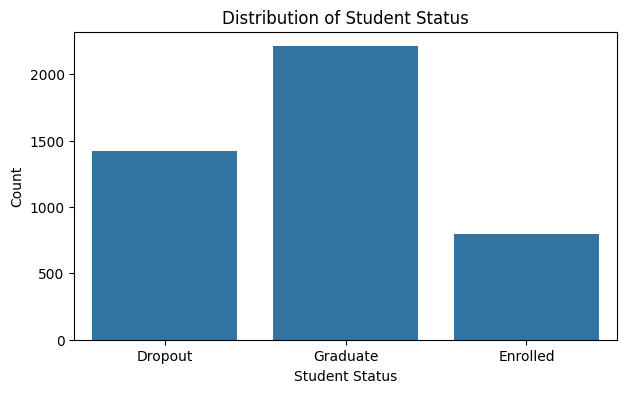


=== STATUS DISTRIBUTION (AFTER FILTER) ===


,count
Status,
Graduate,2209
Dropout,1421



=== TARGET DISTRIBUTION ===


,count
Dropout_Risk,
0,2209
1,1421



=== NUMERICAL EDA ===

--- Age_at_enrollment ---
count    3630.000000
mean       23.461157
std         7.827994
min        17.000000
25%        19.000000
50%        20.000000
75%        25.000000
max        70.000000
Name: Age_at_enrollment, dtype: float64


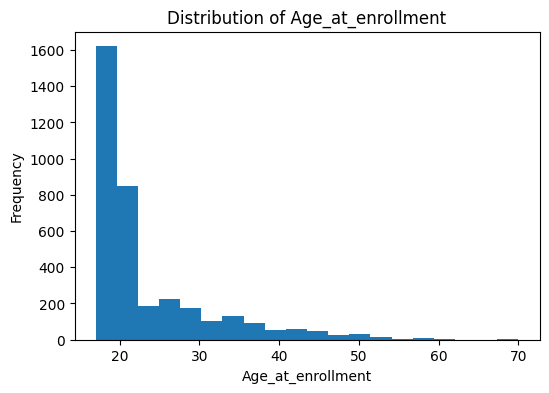


--- Admission_grade ---
count    3630.000000
mean      127.293939
std        14.611295
min        95.000000
25%       118.000000
50%       126.500000
75%       135.100000
max       190.000000
Name: Admission_grade, dtype: float64


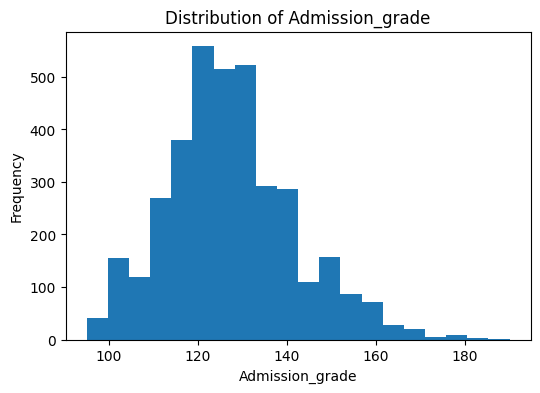


--- Previous_qualification_grade ---
count    3630.000000
mean      132.920606
std        13.238373
min        95.000000
25%       125.000000
50%       133.100000
75%       140.000000
max       190.000000
Name: Previous_qualification_grade, dtype: float64


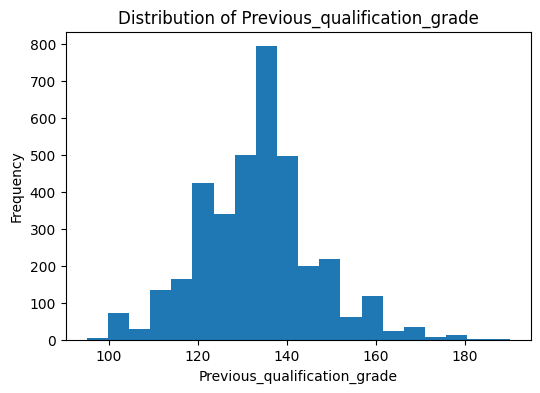


--- Curricular_units_1st_sem_grade ---
count    3630.000000
mean       10.534860
std         5.057694
min         0.000000
25%        11.000000
50%        12.341429
75%        13.500000
max        18.875000
Name: Curricular_units_1st_sem_grade, dtype: float64


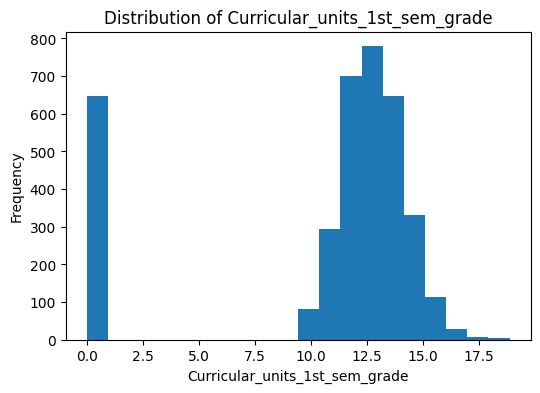


--- Curricular_units_2nd_sem_grade ---
count    3630.000000
mean       10.036155
std         5.481742
min         0.000000
25%        10.517857
50%        12.333333
75%        13.500000
max        18.571429
Name: Curricular_units_2nd_sem_grade, dtype: float64


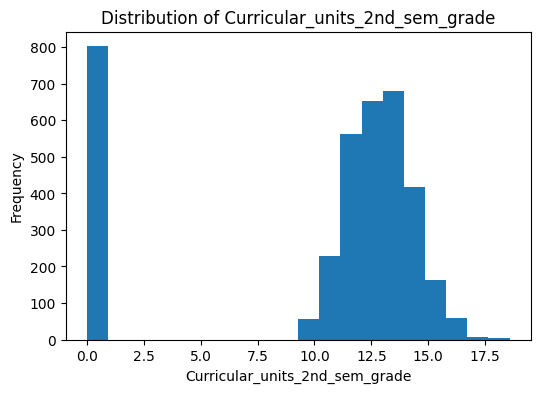


=== STATUS VS NUMERICAL FEATURES ===


,Admission_grade,Age_at_enrollment,Curricular_units_1st_sem_grade,Curricular_units_2nd_sem_grade
Status,,,,
Dropout,124.961365,26.068966,7.256656,5.899339
Graduate,128.794432,21.783612,12.643655,12.697276


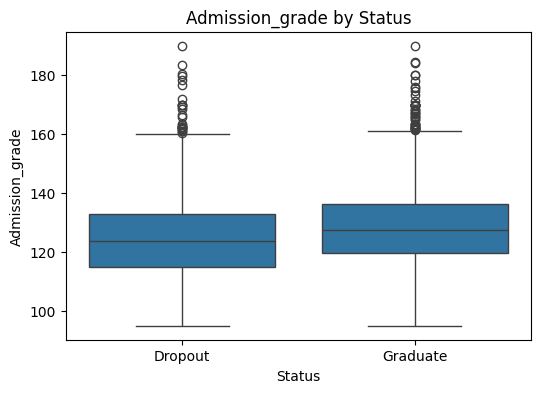

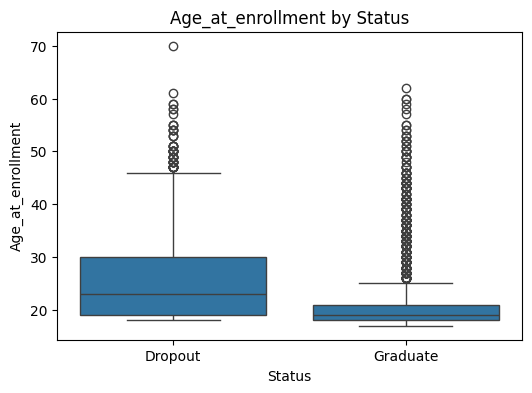

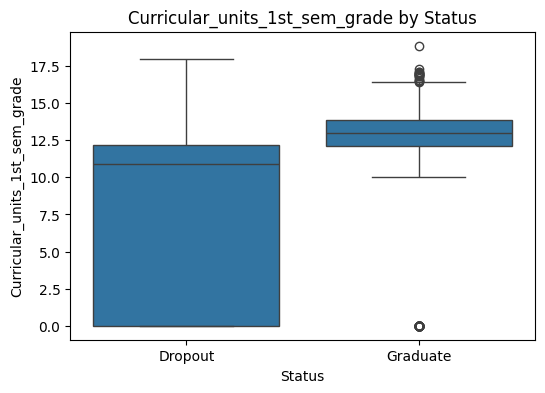

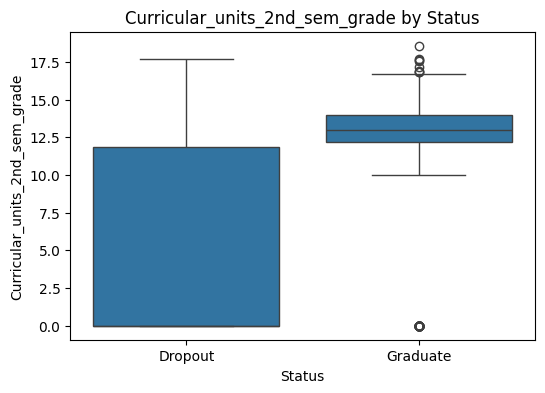


=== CORRELATION MATRIX ===


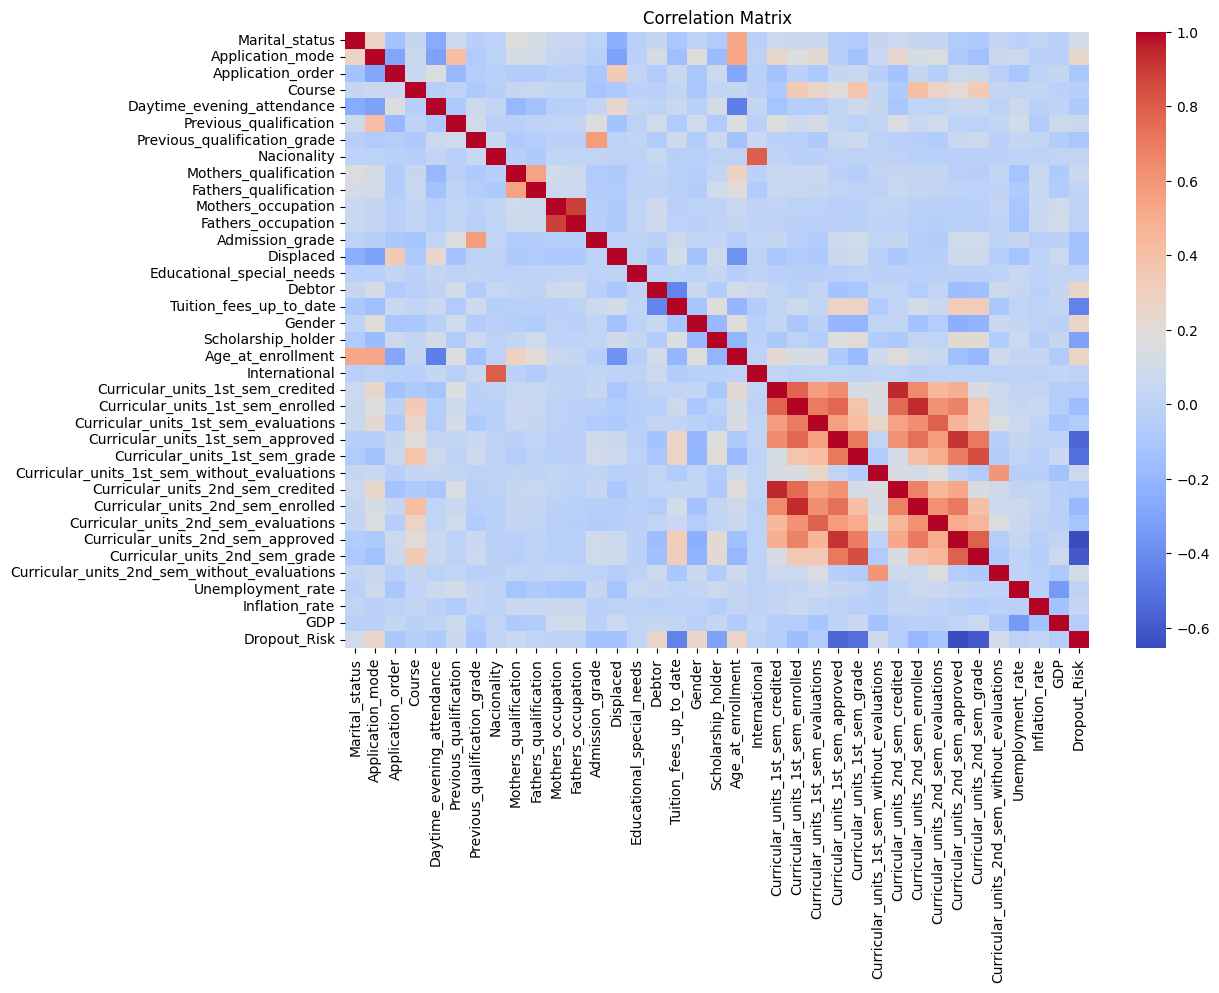

In [2]:
# Upload manual
uploaded = files.upload()

# Get file name
file_name = list(uploaded.keys())[0]
print(f"Uploaded file: {file_name}")

# IMPORTANT FIX -> separator semicolon
df = pd.read_csv(file_name, sep=';')

# Clean column names
df.columns = df.columns.str.strip()

# DATA UNDERSTANDING
print("\n=== PREVIEW DATA ===")
display(df.head())

print("\n=== DATA SHAPE ===")
print(df.shape)

print("\n=== COLUMN NAMES ===")
print(df.columns.tolist())

print("\n=== DATA INFO ===")
df.info()

print("\n=== MISSING VALUES ===")
display(df.isnull().sum())

print("\n=== DESCRIPTIVE STATISTICS ===")
display(df.describe())

# TARGET DISTRIBUTION
print("\n=== DISTRIBUSI STATUS ===")
status_counts = df["Status"].value_counts()
display(status_counts)

plt.figure(figsize=(7,4))
sns.countplot(data=df, x="Status")
plt.title("Distribution of Student Status")
plt.xlabel("Student Status")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

# FILTER hanya Dropout & Graduate
df = df[df["Status"].isin(["Dropout", "Graduate"])].copy()
df.reset_index(drop=True, inplace=True)

print("\n=== STATUS DISTRIBUTION (AFTER FILTER) ===")
display(df["Status"].value_counts())


# TARGET ENGINEERING
df["Dropout_Risk"] = df["Status"].apply(
    lambda x: 1 if x == "Dropout" else 0
)

print("\n=== TARGET DISTRIBUTION ===")
display(df["Dropout_Risk"].value_counts())

# NUMERICAL EDA
eda_cols = [
    "Age_at_enrollment",
    "Admission_grade",
    "Previous_qualification_grade",
    "Curricular_units_1st_sem_grade",
    "Curricular_units_2nd_sem_grade"
]

existing_cols = [col for col in eda_cols if col in df.columns]

print("\n=== NUMERICAL EDA ===")
for col in existing_cols:
    print(f"\n--- {col} ---")
    print(df[col].describe())

    plt.figure(figsize=(6,4))
    plt.hist(df[col].dropna(), bins=20)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

# STATUS VS NUMERIC
print("\n=== STATUS VS NUMERICAL FEATURES ===")

compare_cols = [
    "Admission_grade",
    "Age_at_enrollment",
    "Curricular_units_1st_sem_grade",
    "Curricular_units_2nd_sem_grade"
]

compare_cols = [col for col in compare_cols if col in df.columns]

grouped_mean = df.groupby("Status")[compare_cols].mean()
display(grouped_mean)

for col in compare_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=df, x="Status", y=col)
    plt.title(f"{col} by Status")
    plt.xticks(rotation=0)
    plt.show()

# CORRELATION MATRIX
print("\n=== CORRELATION MATRIX ===")

num_cols = df.select_dtypes(include=[np.number]).columns

corr = df[num_cols].corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

## Data Preparation / Preprocessing

In [3]:
# Copy from Cell 2 dataframe
df_tableau = df.copy()

# BASIC CLEANING
print("Initial shape:", df_tableau.shape)

# Remove duplicates
before_rows = len(df_tableau)
df_tableau = df_tableau.drop_duplicates()
after_rows = len(df_tableau)

print(f"Duplicate rows removed: {before_rows - after_rows}")
print("Shape after cleaning:", df_tableau.shape)

# Check missing values
print("\nRemaining missing values:")
display(df_tableau.isnull().sum())

# FEATURE ENGINEERING FOR TABLEAU

# Age Group
df_tableau["Age_Group"] = pd.cut(
    df_tableau["Age_at_enrollment"],
    bins=[0, 20, 25, 30, 40, 100],
    labels=["<=20", "21-25", "26-30", "31-40", "40+"],
    include_lowest=True
)

# Admission Grade Group
df_tableau["Admission_Grade_Group"] = pd.cut(
    df_tableau["Admission_grade"],
    bins=[0, 100, 120, 140, 160, 200],
    labels=["Low", "Medium", "Good", "Very Good", "Excellent"],
    include_lowest=True
)

# Academic Risk
df_tableau["Academic_Risk"] = pd.cut(
    df_tableau["Curricular_units_1st_sem_approved"],
    bins=[-1, 2, 5, 10, 20],
    labels=["High Risk", "Medium Risk", "Low Risk", "Excellent"],
    include_lowest=True
)

# Tuition label
df_tableau["Tuition_Status_Label"] = df_tableau["Tuition_fees_up_to_date"].map({
    1: "Up to Date",
    0: "Outstanding"
})

# Scholarship label
df_tableau["Scholarship_Label"] = df_tableau["Scholarship_holder"].map({
    1: "Scholarship",
    0: "Non Scholarship"
})

# Gender label
df_tableau["Gender_Label"] = df_tableau["Gender"].map({
    1: "Male",
    0: "Female"
})

# FINAL CHECK
print("\nPreview extract data:")
display(df_tableau.head())

print("\nFinal shape for Tableau:")
print(df_tableau.shape)

# EXPORT CSV + TSV
csv_file = "fact_student.csv"
tsv_file = "fact_student.tsv"

df_tableau.to_csv(csv_file, index=False)
df_tableau.to_csv(tsv_file, index=False, sep="\t")

print("\nFiles exported successfully:")
print(csv_file)
print(tsv_file)

# Download TSV only
from google.colab import files
files.download(tsv_file)

Initial shape: (3630, 38)
Duplicate rows removed: 0
Shape after cleaning: (3630, 38)

Remaining missing values:


,0
Marital_status,0
Application_mode,0
Application_order,0
Course,0
Daytime_evening_attendance,0
Previous_qualification,0
Previous_qualification_grade,0
Nacionality,0
Mothers_qualification,0
Fathers_qualification,0



Preview extract data:


,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Inflation_rate,GDP,Status,Dropout_Risk,Age_Group,Admission_Grade_Group,Academic_Risk,Tuition_Status_Label,Scholarship_Label,Gender_Label
0,1,17,5,171,1,1,122.0,1,19,12,...,1.4,1.74,Dropout,1,<=20,Good,High Risk,Up to Date,Non Scholarship,Male
1,1,15,1,9254,1,1,160.0,1,1,3,...,-0.3,0.79,Graduate,0,<=20,Very Good,Low Risk,Outstanding,Non Scholarship,Male
2,1,1,5,9070,1,1,122.0,1,37,37,...,1.4,1.74,Dropout,1,<=20,Good,High Risk,Outstanding,Non Scholarship,Male
3,1,17,2,9773,1,1,122.0,1,38,37,...,-0.8,-3.12,Graduate,0,<=20,Medium,Low Risk,Up to Date,Non Scholarship,Female
4,2,39,1,8014,0,1,100.0,1,37,38,...,-0.3,0.79,Graduate,0,40+,Very Good,Medium Risk,Up to Date,Non Scholarship,Female



Final shape for Tableau:
(3630, 44)

Files exported successfully:
fact_student.csv
fact_student.tsv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Modeling

In [6]:
# Copy dataframe from Cell 2
df_model = df.copy()

# FEATURE SELECTION (MATCH STREAMLIT)

selected_features = [
    "Admission_grade",
    "Age_at_enrollment",
    "Tuition_fees_up_to_date",
    "Scholarship_holder",
    "Debtor",
    "Curricular_units_1st_sem_approved",
    "Curricular_units_1st_sem_grade",
    "Curricular_units_2nd_sem_grade"
]

X = df_model[selected_features]
y = df_model["Dropout_Risk"]

print("\n=== FEATURE USED ===")
print(selected_features)


# TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)


# MODEL TRAINING

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)


# PREDICTION

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]


# SAVE ARTIFACTS (PENTING UNTUK STREAMLIT)

joblib.dump(model, "student_dropout_model.pkl")
joblib.dump(list(X.columns), "model_features.pkl")

print("\n=== MODEL ARTIFACT SAVED ===")
print("student_dropout_model.pkl")
print("model_features.pkl")


=== FEATURE USED ===
['Admission_grade', 'Age_at_enrollment', 'Tuition_fees_up_to_date', 'Scholarship_holder', 'Debtor', 'Curricular_units_1st_sem_approved', 'Curricular_units_1st_sem_grade', 'Curricular_units_2nd_sem_grade']

Train shape: (2904, 8)
Test shape: (726, 8)

=== MODEL ARTIFACT SAVED ===
student_dropout_model.pkl
model_features.pkl


## Evaluation

=== MODEL PERFORMANCE ===
Accuracy Score : 0.8898
F1 Score       : 0.8540
ROC AUC Score  : 0.9408

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0       0.89      0.93      0.91       442
           1       0.89      0.82      0.85       284

    accuracy                           0.89       726
   macro avg       0.89      0.88      0.88       726
weighted avg       0.89      0.89      0.89       726



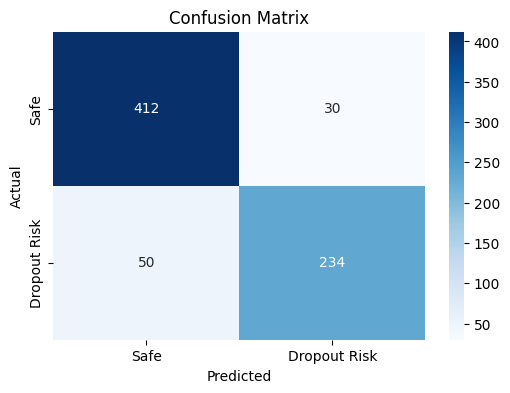

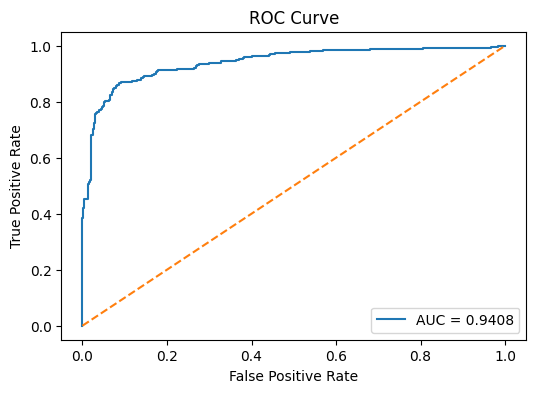

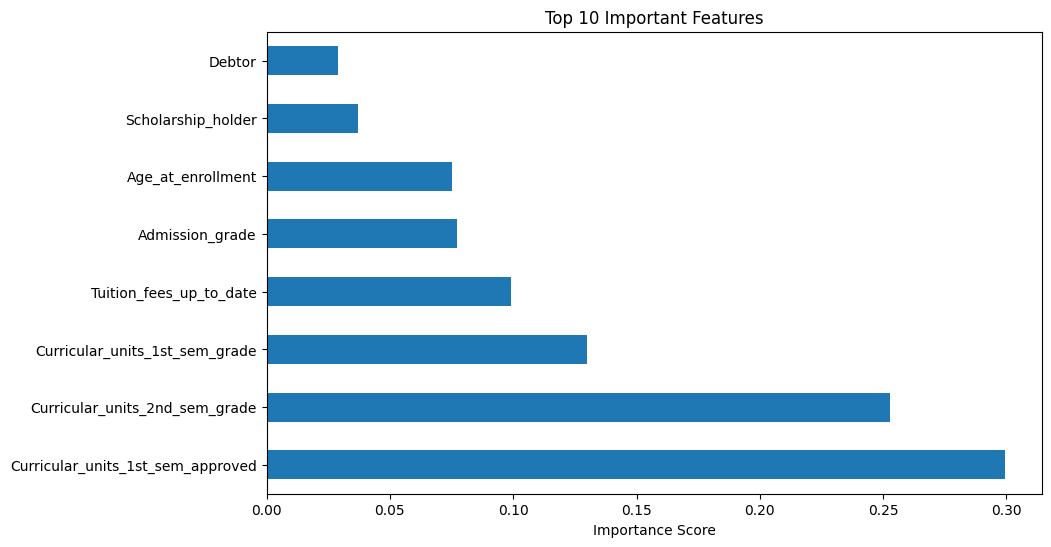


=== APP RISK THRESHOLD ===
Threshold: 0.5

Rule:
Probability >= 0.50 → High Risk
Probability < 0.50  → Low Risk

=== MODEL PERFORMANCE ===
Accuracy  : 0.8898
Precision : 0.8864
Recall    : 0.8239
F1-score  : 0.8540

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0       0.89      0.93      0.91       442
           1       0.89      0.82      0.85       284

    accuracy                           0.89       726
   macro avg       0.89      0.88      0.88       726
weighted avg       0.89      0.89      0.89       726



In [9]:
# METRICS

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc_score = roc_auc_score(y_test, y_prob)

print("=== MODEL PERFORMANCE ===")
print(f"Accuracy Score : {accuracy:.4f}")
print(f"F1 Score       : {f1:.4f}")
print(f"ROC AUC Score  : {auc_score:.4f}")

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred))

# CONFUSION MATRIX

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Safe", "Dropout Risk"],
    yticklabels=["Safe", "Dropout Risk"]
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC CURVE

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# FEATURE IMPORTANCE

feature_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,6))
feature_importance.head(10).plot(kind="barh")
plt.title("Top 10 Important Features")
plt.xlabel("Importance Score")
plt.show()

# RISK THRESHOLD FOR APP

risk_threshold = 0.5

print("\n=== APP RISK THRESHOLD ===")
print(f"Threshold: {risk_threshold}")

print("\nRule:")
print("Probability >= 0.50 → High Risk")
print("Probability < 0.50  → Low Risk")

# MODEL EVALUATION

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\n=== MODEL PERFORMANCE ===")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred))